Bin   | Delta q2   | Eff_sig (%)     | dBF/dq2        
-------------------------------------------------------
0     | 0.90       | 14.83          | 2.36e-09       
1     | 2.30       | 17.46          | 2.82e-09       
2     | 1.70       | 16.95          | 3.35e-09       
3     | 2.68       | 16.61          | 4.48e-09       
4     | 1.41       | 18.36          | 6.46e-06       
5     | 2.77       | 19.46          | 4.93e-08       
6     | 1.32       | 20.87          | 5.57e-07       
7     | 1.82       | 26.05          | 1.94e-08       
8     | 3.00       | 34.78          | 1.13e-08       


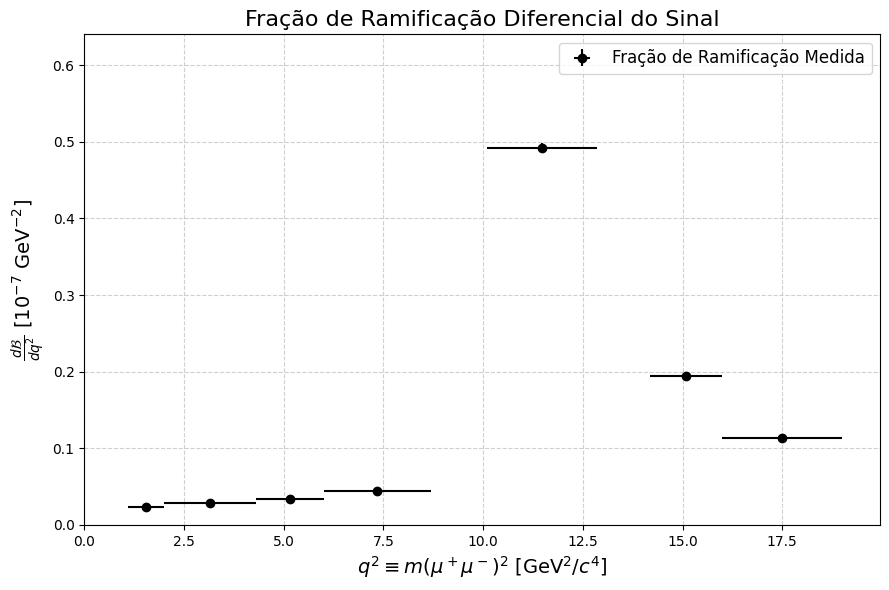

In [1]:
import numpy as np
import matplotlib.pyplot as plt

N_norm = 650616  
BF_B0_KstJpsi = 1.27e-3   # B(B0 -> K*0 J/psi)
BF_Jpsi_mumu = 5.961e-2   # B(J/psi -> mu+mu)

dados = [
    {"bin": 0, "q2_min": 1.1,  "q2_max": 2.0,  "nsig": 122.9,    "n_gen": 991,  "n_reco": 147},
    {"bin": 1, "q2_min": 2.0,  "q2_max": 4.3,  "nsig": 319.5,    "n_gen": 2491, "n_reco": 435},
    {"bin": 2, "q2_min": 4.3,  "q2_max": 6.0,  "nsig": 288.4,    "n_gen": 2147, "n_reco": 364},
    {"bin": 3, "q2_min": 6.0,  "q2_max": 8.68, "nsig": 620.8,    "n_gen": 4527, "n_reco": 752},
    {"bin": 4, "q2_min": 8.68, "q2_max": 10.09,"nsig": 426689.3, "n_gen": 3034, "n_reco": 557},  # Ressonância J/psi
    {"bin": 5, "q2_min": 10.09,"q2_max": 12.86,"nsig": 6023.8,   "n_gen": 6232, "n_reco": 1213},
    {"bin": 6, "q2_min": 12.86,"q2_max": 14.18,"nsig": 30256.1,  "n_gen": 2760, "n_reco": 576},  # Ressonância psi(2S)
    {"bin": 7, "q2_min": 14.18,"q2_max": 16.0, "nsig": 1166.6,   "n_gen": 2917, "n_reco": 760},
    {"bin": 8, "q2_min": 16.0, "q2_max": 19.0, "nsig": 835.5,    "n_gen": 1906, "n_reco": 663}, 
]

q2_centers = []
q2_errors = []
dbf_dq2_vals = []
dbf_errors = []

print(f"{'Bin':<5} | {'Delta q2':<10} | {'Eff_sig (%)':<15} | {'dBF/dq2':<15}")
print("-" * 55)

for d in dados:
    delta_q2 = d["q2_max"] - d["q2_min"]
    q2_center = (d["q2_max"] + d["q2_min"]) / 2.0
    
    # Razão de eficiência
    eff_ratio = d["n_reco"] / d["n_gen"]
    
    termo_yield = d["nsig"] / N_norm
    termo_bf = BF_B0_KstJpsi * BF_Jpsi_mumu
    
    # Cálculo da Fração de Ramificação Diferencial
    dbf_dq2 = termo_yield * eff_ratio * (1.0 / delta_q2) * termo_bf
    
    # Propagação do erro (considerando apenas o erro estatístico do yield do sinal para simplificar)
    erro_nsig = np.sqrt(d["nsig"])
    erro_dbf = (erro_nsig / N_norm) * eff_ratio * (1.0 / delta_q2) * termo_bf
    
    # Imprime todos os resultados na tabela
    print(f"{d['bin']:<5} | {delta_q2:<10.2f} | {eff_ratio*100:<14.2f} | {dbf_dq2:<15.2e}")
    
    # Condição para NÃO plotar os bins de ressonância 4 e 6
    if d["bin"] not in [4, 6]:
        # Multiplicando por 1e7 para o plot ficar com a escala (10^-7)
        dbf_plot = dbf_dq2 * 1e7
        erro_plot = erro_dbf * 1e7
        
        q2_centers.append(q2_center)
        q2_errors.append(delta_q2 / 2.0)
        dbf_dq2_vals.append(dbf_plot)
        dbf_errors.append(erro_plot)

# --- PLOT ---
plt.figure(figsize=(9, 6))

# Plota os pontos com barras de erro (X e Y)
plt.errorbar(q2_centers, dbf_dq2_vals, xerr=q2_errors, yerr=dbf_errors, 
             fmt='o', color='black', ecolor='black', capsize=0, 
             markersize=6, label='Fração de Ramificação Medida')

plt.title(r'Fração de Ramificação Diferencial do Sinal', fontsize=16)
plt.xlabel(r'$q^2 \equiv m(\mu^+\mu^-)^2$ [GeV$^2/c^4$]', fontsize=14)
plt.ylabel(r'$\frac{d\mathcal{B}}{dq^2} \ [10^{-7} \ \mathrm{GeV}^{-2}]$', fontsize=14)

# Ajuste dinâmico dos limites do eixo X (ignora os bins de ressonância para o limite máximo de X, caso precise)
plt.xlim(0, max([d["q2_max"] for d in dados if d["bin"] not in [4, 6]]) * 1.05)
plt.ylim(0, max(dbf_dq2_vals) * 1.3)

plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=12)

plt.tight_layout()
plt.show()

Bin   | Delta q2   | Eff_sig (%)     | dBF/dq2        
-------------------------------------------------------
0     | 0.90       | 0.24           | 2.81e-09       
1     | 2.30       | 0.30           | 2.24e-09       
2     | 1.70       | 0.31           | 2.69e-09       
3     | 2.68       | 0.33           | 3.45e-09       
4     | 1.41       | 0.42           | 3.55e-06       
5     | 2.77       | 0.44           | 2.43e-08       
6     | 1.32       | 0.44           | 2.53e-07       
7     | 1.82       | 0.47           | 6.69e-09       
8     | 3.00       | 0.41           | 3.35e-09       


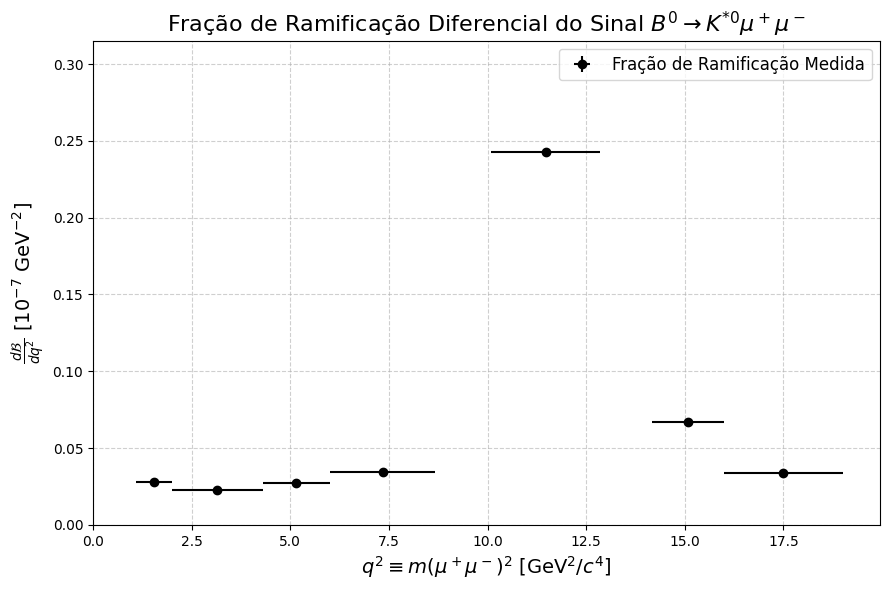

In [2]:
import numpy as np
import matplotlib.pyplot as plt

N_norm = 650616        # Yield obtido do fit nos dados da região do J/psi
BF_B0_KstJpsi = 1.27e-3   # B(B0 -> K*0 J/psi)
BF_Jpsi_mumu = 5.961e-2   # B(J/psi -> mu+mu)

N_reco_norm = 6362
N_gen_norm  = 15144254
eff_norm = N_reco_norm / N_gen_norm

dados = [
    {"bin": 0, "q2_min": 1.1,  "q2_max": 2.0,  "nsig": 122.9,    "n_gen": 61845,  "n_reco": 147},
    {"bin": 1, "q2_min": 2.0,  "q2_max": 4.3,  "nsig": 319.5,    "n_gen": 143266, "n_reco": 435},
    {"bin": 2, "q2_min": 4.3,  "q2_max": 6.0,  "nsig": 288.4,    "n_gen": 118189, "n_reco": 364},
    {"bin": 3, "q2_min": 6.0,  "q2_max": 8.68, "nsig": 620.8,    "n_gen": 228947, "n_reco": 752},
    {"bin": 4, "q2_min": 8.68, "q2_max": 10.09,"nsig": 426689.3, "n_gen": 133731, "n_reco": 557},  # Vetado (J/psi)
    {"bin": 5, "q2_min": 10.09,"q2_max": 12.86,"nsig": 6023.8,   "n_gen": 276722, "n_reco": 1213},
    {"bin": 6, "q2_min": 12.86,"q2_max": 14.18,"nsig": 30256.1,  "n_gen": 130098, "n_reco": 576},  # Vetado psi(2S)
    {"bin": 7, "q2_min": 14.18,"q2_max": 16.0, "nsig": 1166.6,   "n_gen": 162287, "n_reco": 760},
    {"bin": 8, "q2_min": 16.0, "q2_max": 19.0, "nsig": 835.5,    "n_gen": 163111, "n_reco": 663}, 
]

q2_centers = []
q2_errors = []
dbf_dq2_vals = []
dbf_errors = []

print(f"{'Bin':<5} | {'Delta q2':<10} | {'Eff_sig (%)':<15} | {'dBF/dq2':<15}")
print("-" * 55)

# O Fator Constante Global da equação: (eff_Jpsi / N_Jpsi) * B_KstJpsi * B_Jpsimumu
fator_normalizacao_global = (eff_norm / N_norm) * BF_B0_KstJpsi * BF_Jpsi_mumu

for d in dados:
    delta_q2 = d["q2_max"] - d["q2_min"]
    q2_center = (d["q2_max"] + d["q2_min"]) / 2.0
    
    # Eficiência do sinal NESTE bin específico
    eff_sig_i = d["n_reco"] / d["n_gen"]
    
    # O termo que muda a cada bin na equação: N_sig,i / (eff_sig,i * delta_q2)
    termo_sinal_dinamico = d["nsig"] / (eff_sig_i * delta_q2)
    
    # CÁLCULO FINAL: Multiplicação do termo do bin com a constante global
    dbf_dq2 = termo_sinal_dinamico * fator_normalizacao_global
    
    # Propagação do erro estatístico (considerando apenas o erro do yield do sinal)
    erro_nsig = np.sqrt(d["nsig"])
    erro_termo_sinal = erro_nsig / (eff_sig_i * delta_q2)
    erro_dbf = erro_termo_sinal * fator_normalizacao_global
    
    print(f"{d['bin']:<5} | {delta_q2:<10.2f} | {eff_sig_i*100:<14.2f} | {dbf_dq2:<15.2e}")
    
    # Condição para NÃO plotar os bins de ressonância 4 e 6
    if d["bin"] not in [4, 6]:
        # Multiplicando por 1e7 para o plot ficar com a escala (10^-7)
        dbf_plot = dbf_dq2 * 1e7
        erro_plot = erro_dbf * 1e7
        
        q2_centers.append(q2_center)
        q2_errors.append(delta_q2 / 2.0)
        dbf_dq2_vals.append(dbf_plot)
        dbf_errors.append(erro_plot)

# ==============================================================================
# PLOT
# ==============================================================================
plt.figure(figsize=(9, 6))

# Plota os pontos com barras de erro (X e Y)
plt.errorbar(q2_centers, dbf_dq2_vals, xerr=q2_errors, yerr=dbf_errors, 
             fmt='o', color='black', ecolor='black', capsize=0, 
             markersize=6, label='Fração de Ramificação Medida')

plt.title(r'Fração de Ramificação Diferencial do Sinal $B^0 \to K^{*0}\mu^+\mu^-$', fontsize=16)
plt.xlabel(r'$q^2 \equiv m(\mu^+\mu^-)^2$ [GeV$^2/c^4$]', fontsize=14)
plt.ylabel(r'$\frac{d\mathcal{B}}{dq^2} \ [10^{-7} \ \mathrm{GeV}^{-2}]$', fontsize=14)

# Ajuste dinâmico dos limites do eixo X
max_x = max([d["q2_max"] for d in dados if d["bin"] not in [4, 6]])
plt.xlim(0, max_x * 1.05)

# Ajuste do eixo Y para garantir que os pontos não encostem no topo
plt.ylim(0, max(dbf_dq2_vals) * 1.3)

plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=12)

plt.tight_layout()
plt.show()